# 07 - RESUME EXTRACTIF PAR MMR

Module 3 -- *Résumer*. On sélectionne dans chaque livre les `k` phrases qui le caracterisent le mieux, en évitant la redondance, par **Maximal Marginal Relevance**.

**Pipeline** : DataFrame annoté -> phrases (filtrées, reconstruites) -> matrice TF-IDF des phrases -> centre du livre -> selection MMR de k phrases.

Toute la logique vit dans `pipeline.summarization`. Ce notebook l'utilise pour étudier l'effet de lambda, comparer lemmes vs tokens, visualiser les phrases en 2D, et générer les résumés finaux pour tout le corpus.


## Setup

In [1]:
import sys
from pathlib import Path

# Se déplacer dans le dossier du projet (NE LANCER Q'UNE FOIS)
%cd ../
%ls

/home/gau/projets/nlp/projet_nlp_app
README.md  figures/  notebooks/      pipeline/         scripts/
app/       models/   pg_catalog.csv  requirements.txt


In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from pipeline import storage
from pipeline.config import MMR_PARAMS, PREFIXES
from pipeline.corpus import charger_corpus, trouver_livre
from pipeline.parsing import construire_cle
from pipeline.representations import TfIdfMaison
from pipeline.summarization import (
    extraire_phrases, formatter_resume, mmr, resumer_livre, vecteur_centre,
)

CFG = {
    "figures_dir":     Path("figures"),
    "k_phrases":       MMR_PARAMS["k_phrases"],
    "lambda_default":  MMR_PARAMS["lambda_default"],
    "min_tokens":      MMR_PARAMS["min_tokens_phrase"],
    "min_df":          MMR_PARAMS["min_df"],
}
CFG["figures_dir"].mkdir(exist_ok=True)

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 100
plt.rcParams["savefig.dpi"] = 150
plt.rcParams["savefig.bbox"] = "tight"

## Chargement

In [3]:
corpus = charger_corpus()

Chargement de 26 livres annotes...
  26 livres charges


## Résumé d'un livre témoin

On choisit un livre comme cas d'école pour illustrer l'effet de lambda.


In [4]:
livre = trouver_livre(corpus, "zola") if any("zola" in c["auteur"].lower() for c in corpus) else corpus[0]
print(f"Livre temoin : {livre['auteur']} -- {livre['livre']}")
print(f"  {len(livre['df']):,} tokens annotes, {livre['df']['sent_id'].nunique():,} phrases")

phrases = extraire_phrases(livre["df"], champ_termes="lemma", min_tokens=CFG["min_tokens"])
print(f"  {len(phrases)} phrases retenues (apres filtre min_tokens={CFG['min_tokens']})")

Livre temoin : Zola Emile -- Au Bonheur Des Dames
  189,596 tokens annotes, 10,022 phrases
  1667 phrases retenues (apres filtre min_tokens=12)


## Effet du paramètre lambda

`lambda` contrôle le compromis entre **pertinence** (similarité avec le centre du livre) et **diversite** (anti-redondance avec les phrases déjà selectionnées).

- `lambda = 1.0` : pertinence pure -> les k phrases les plus centrales (souvent redondantes)
- `lambda = 0.5` : équilibre
- `lambda = 0.0` : diversité pure -> minimise la redondance, sans tenir compte de la pertinence

On compare 4 valeurs sur le livre témoin.


In [5]:
vec = TfIdfMaison(ngram_max=1, min_df=CFG["min_df"]).fit_transform(
    [p["termes"] for p in phrases]
)
centre = vecteur_centre(vec)

for lam in [0.3, 0.5, 0.7, 0.9]:
    indices = mmr(vec, centre, k=CFG["k_phrases"], lambda_=lam)
    print(f"\n--- lambda = {lam} ---")
    for rang, i in enumerate(indices, 1):
        texte = phrases[i]["texte"]
        if len(texte) > 110:
            texte = texte[:107] + "..."
        print(f"  [{rang:2d}]  {texte}")



--- lambda = 0.3 ---
  [ 1]  Elle seule continuait à approuver la seconde de résister à Mouret, hochant la tête, n'avouant pas l'enfant ...
  [ 2]  et, partout, rangées symétriquement, bariolant les murs de rouge, de vert et de jaune, elles semblaient de ...
  [ 3]  Il se nommait Hutin, était le fils d'un cafetier d'Yvetot, et avait su, en dix-huit mois, devenir un des pr...
  [ 4]  Il en gardait une rancune, il voyait en Robineau l'instrument d'une bataille décisive, livrée à ces bazars ...
  [ 5]  Cependant, Denise s'approcha, attirée par la pitié active, qui la faisait se mêler de tous les accidents, d...
  [ 6]  En vain, il battait la maison: l'idée fixe restait enfoncée entre ses deux yeux, et à mesure que sa puissan...
  [ 7]  Gaujean accourut de Lyon, il y eut des conciliabules effarés, on finit par prendre une résolution héroïque:...
  [ 8]  et, comme ces demoiselles du rayon l'empêchaient de vendre, elle arrivait tout juste à payer la pension de ...
  [ 9]  Le blanc défilait:

## Mesures quantitatives : pertinence vs redondance

On mesure :
- **Pertinence moyenne** : moyenne des cosinus des phrases selectionnées avec le centre du livre.
- **Redondance moyenne** : moyenne des cosinus entre paires de phrases selectionnées (plus haut = plus redondant).

`lambda` augmente -> pertinence augmente -> redondance augmente aussi.


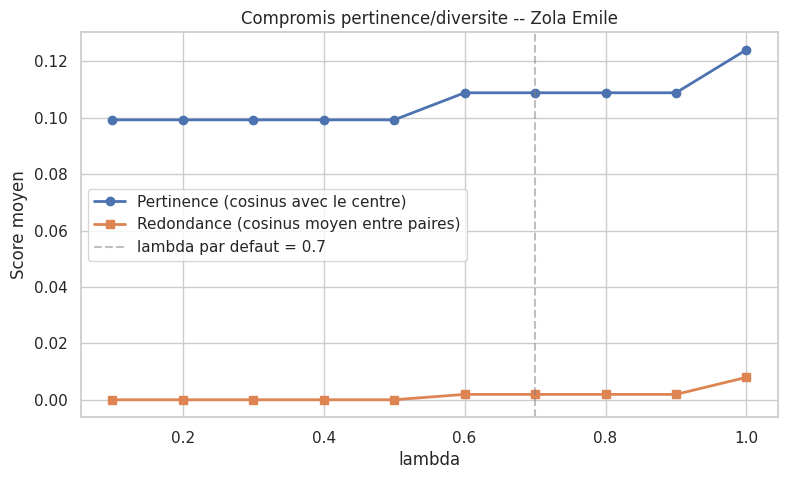

In [6]:
def metriques_selection(vec, centre, indices):
    M = vec[indices]
    pertinence = float((M @ centre).mean())
    if len(indices) > 1:
        sims = M @ M.T
        # On prend le triangle superieur strict (sans la diagonale)
        ii, jj = np.triu_indices_from(sims, k=1)
        redondance = float(sims[ii, jj].mean())
    else:
        redondance = 0.0
    return pertinence, redondance

mesures = []
for lam in np.linspace(0.1, 1.0, 10):
    indices = mmr(vec, centre, k=CFG["k_phrases"], lambda_=float(lam))
    pert, red = metriques_selection(vec, centre, indices)
    mesures.append({"lambda": float(lam), "pertinence": pert, "redondance": red})

mesures_df = pd.DataFrame(mesures)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(mesures_df["lambda"], mesures_df["pertinence"],
        "o-", label="Pertinence (cosinus avec le centre)", linewidth=2)
ax.plot(mesures_df["lambda"], mesures_df["redondance"],
        "s-", label="Redondance (cosinus moyen entre paires)", linewidth=2)
ax.axvline(CFG["lambda_default"], color="grey", linestyle="--", alpha=0.5,
           label=f"lambda par defaut = {CFG['lambda_default']}")
ax.set_xlabel("lambda")
ax.set_ylabel("Score moyen")
ax.set_title(f"Compromis pertinence/diversite -- {livre['auteur']}")
ax.legend()
plt.savefig(CFG["figures_dir"] / "mmr_lambda.png")
plt.show()


## Lemmes vs tokens (formes fléchies)

Faut-il representer les phrases avec leurs lemmes (forme canonique) ou leurs tokens (formes fléchies brutes) ?


In [7]:
resume_lemmes = resumer_livre(
    livre["df"], champ_termes="lemma",
    k=CFG["k_phrases"], lambda_=CFG["lambda_default"],
)
resume_tokens = resumer_livre(
    livre["df"], champ_termes="text",
    k=CFG["k_phrases"], lambda_=CFG["lambda_default"],
)

ids_lemmes = {p["sent_id"] for p in resume_lemmes}
ids_tokens = {p["sent_id"] for p in resume_tokens}
communes = ids_lemmes & ids_tokens

print(f"Phrases selectionnees -- lemmes : {sorted(ids_lemmes)}")
print(f"Phrases selectionnees -- tokens : {sorted(ids_tokens)}")
print(f"Recouvrement                    : {len(communes)} / {CFG['k_phrases']} phrases communes")


/home/gau/projets/nlp/.venv/lib/python3.12/site-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


Phrases selectionnees -- lemmes : [657, 996, 1007, 1847, 1849, 2130, 4354, 8396, 9658, 9929]
Phrases selectionnees -- tokens : [657, 996, 1007, 1847, 1849, 2130, 4354, 8396, 9658, 9929]
Recouvrement                    : 10 / 10 phrases communes


## Visualisation 2D des phrases selectionnées

On projette toutes les phrases du livre dans le plan PCA, et on met en évidence celles selectionnées par MMR. Si la diversité fonctionne, les phrases selectionnées doivent etre **étalées** dans le nuage et non pas concentrées au centre.


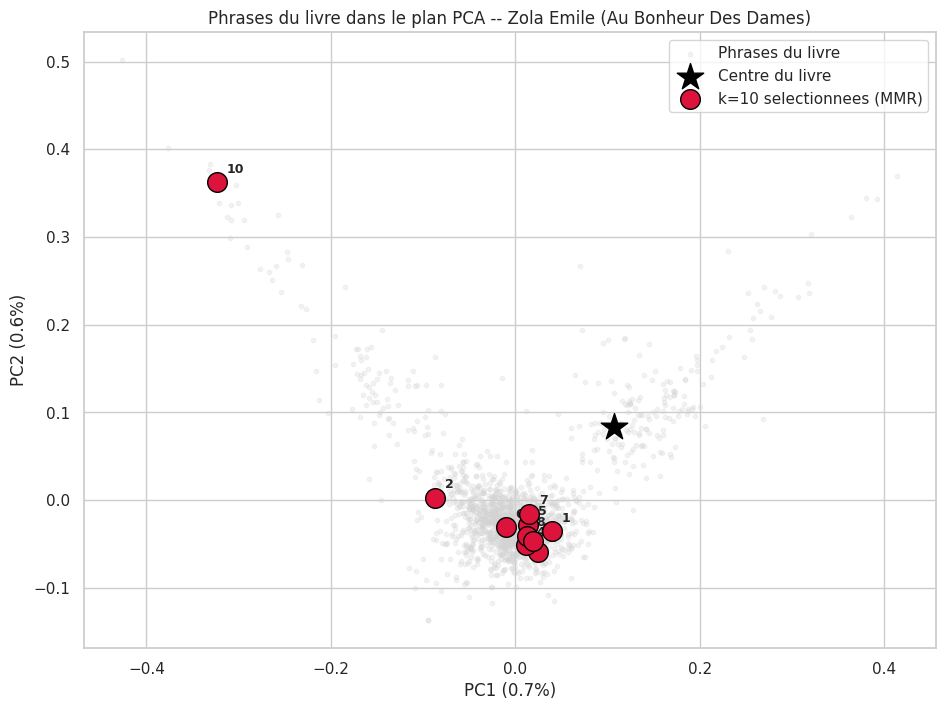

In [8]:
from sklearn.decomposition import PCA

# PCA sur la matrice TF-IDF des phrases (espace dense potentiellement gros, on demande 2 composantes)
pca = PCA(n_components=2, random_state=0)
phrases_2d = pca.fit_transform(vec)
centre_2d = pca.transform(centre[np.newaxis, :])[0]

indices_default = mmr(vec, centre, k=CFG["k_phrases"], lambda_=CFG["lambda_default"])

fig, ax = plt.subplots(figsize=(11, 8))
ax.scatter(phrases_2d[:, 0], phrases_2d[:, 1],
           s=10, alpha=0.25, color="lightgray", label="Phrases du livre")
ax.scatter(*centre_2d, marker="*", s=400, color="black", zorder=5,
           label="Centre du livre")
selectionnees = phrases_2d[indices_default]
ax.scatter(selectionnees[:, 0], selectionnees[:, 1],
           s=200, color="crimson", edgecolor="black", linewidth=1, zorder=4,
           label=f"k={CFG['k_phrases']} selectionnees (MMR)")
for rang, i in enumerate(indices_default, 1):
    ax.annotate(str(rang), phrases_2d[i],
                xytext=(7, 7), textcoords="offset points",
                fontsize=9, fontweight="bold")

ax.set_title(f"Phrases du livre dans le plan PCA -- {livre['auteur']} ({livre['livre']})")
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%})")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%})")
ax.legend(loc="best")
plt.savefig(CFG["figures_dir"] / "mmr_phrases_2d.png")
plt.show()


## Visualisation 3D autonome (HTML)

Comme la PCA 2D ne capture qu'une fraction de la variance, on exporte une vue Plotly 3D interactive en HTML autonome (a ouvrir dans le navigateur).


In [9]:
import plotly.graph_objects as go

pca3 = PCA(n_components=3, random_state=0)
phrases_3d = pca3.fit_transform(vec)
centre_3d = pca3.transform(centre[np.newaxis, :])[0]

textes_courts = [
    p["texte"][:120] + ("..." if len(p["texte"]) > 120 else "")
    for p in phrases
]

fig3d = go.Figure()
fig3d.add_trace(go.Scatter3d(
    x=phrases_3d[:, 0], y=phrases_3d[:, 1], z=phrases_3d[:, 2],
    mode="markers",
    marker=dict(size=3, color="lightgray", opacity=0.5),
    name="Phrases",
    text=textes_courts, hoverinfo="text",
))
fig3d.add_trace(go.Scatter3d(
    x=phrases_3d[indices_default, 0],
    y=phrases_3d[indices_default, 1],
    z=phrases_3d[indices_default, 2],
    mode="markers+text",
    marker=dict(size=8, color="crimson", line=dict(color="black", width=1)),
    text=[str(r) for r in range(1, len(indices_default) + 1)],
    textposition="top center",
    name="MMR selection",
    hovertext=[textes_courts[i] for i in indices_default],
    hoverinfo="text",
))
fig3d.add_trace(go.Scatter3d(
    x=[centre_3d[0]], y=[centre_3d[1]], z=[centre_3d[2]],
    mode="markers", marker=dict(size=10, color="black", symbol="diamond"),
    name="Centre", hovertext=["Centre du livre"], hoverinfo="text",
))
fig3d.update_layout(
    title=f"Phrases en 3D -- {livre['auteur']} ({livre['livre']})",
    scene=dict(
        xaxis_title=f"PC1 ({pca3.explained_variance_ratio_[0]:.1%})",
        yaxis_title=f"PC2 ({pca3.explained_variance_ratio_[1]:.1%})",
        zaxis_title=f"PC3 ({pca3.explained_variance_ratio_[2]:.1%})",
    ),
    width=900, height=700,
)
fig3d.write_html(CFG["figures_dir"] / "mmr_phrases_3d.html")
print(f"HTML autonome ecrit : {CFG['figures_dir'] / 'mmr_phrases_3d.html'}")
fig3d.show()


HTML autonome ecrit : figures/mmr_phrases_3d.html


## Génération et upload des résumés pour tout le corpus

Pour chaque livre, on calcule un resume MMR avec les parametres par defaut (`k=10`, `lambda=0.7`), et on l'uploade sous `summaries/genre/auteur/livre.txt`.


In [10]:
for c in corpus:
    phrases_sel = resumer_livre(
        c["df"], champ_termes="lemma",
        k=CFG["k_phrases"], lambda_=CFG["lambda_default"],
    )
    resume = formatter_resume(
        phrases_sel,
        livre=c["livre"], auteur=c["auteur"], genre=c["genre"],
        k=CFG["k_phrases"], lambda_=CFG["lambda_default"],
    )
    cle = construire_cle(
        PREFIXES["summaries"], c["genre"], c["auteur_slug"], c["livre_slug"], ".txt",
    )
    storage.put_text(
        cle, resume,
        metadata={
            "source": "summary_mmr",
            "k":      str(CFG["k_phrases"]),
            "lambda": str(CFG["lambda_default"]),
        },
    )
    print(f"  {c['auteur']:35s} -> {cle}")


  Dumas Alexandre                     -> summaries/adventure/dumas_alexandre/pg17990_le_comte_de_monte_cristo_tome_ii.txt
  Raspe Rudolf Erich                  -> summaries/adventure/raspe_rudolf_erich/pg50398_aventures_de_baron_de_munchausen.txt
  Fusil Louise                        -> summaries/biography/fusil_louise/pg26720_souvenirs_dune_actrice_23.txt
  Marmont Auguste Frederic Louis Viesse De Duc De Raguse -> summaries/biography/marmont_auguste_frederic_louis_viesse_de_duc_de_raguse/pg30013_memoires_du_marechal_marmont_duc_de_raguse_39.txt
  Rouquette Louis Frederic            -> summaries/biography/rouquette_louis_frederic/pg70801_lepopee_blanche.txt
  Savary Anne Jean Marie Rene Duc De Rovigo -> summaries/biography/savary_anne_jean_marie_rene_duc_de_rovigo/pg20895_memoires_du_duc_de_rovigo_pour_servir_a_lhistoire_de_lempereur_napoleon_tome_2.txt
  Stendhal                            -> summaries/biography/stendhal/pg30977_la_vie_de_rossini_tome_i.txt
  Dumas Alexandre          

## Apercu d'un résumé final

In [14]:
cle_demo = construire_cle(
    PREFIXES["summaries"], livre["genre"], livre["auteur_slug"], livre["livre_slug"], ".txt",
)
print(storage.get_text(cle_demo))


Au Bonheur Des Dames
Zola Emile  (novel)
Resume extractif - 10 phrases - MMR lambda=0.7

[ 1] Puis, quand elle y était enfin entrée, pour échapper aux commis du blanc qui riaient, elle avait comme buté tout d'un coup contre l'étalage de Mouret; et, malgré son effarement, la femme se réveillant en elle, les joues subitement rouges, elle s'oubliait à regarder flamber l'incendie des soies.

[ 2] Elle continuait de tirer son aiguille, pendant que le vieillard lâchait d'autres phrases entrecoupées, entre deux entailles de son canif: ça commençait à peine, on verrait plus tard des choses extraordinaires, il avait des idées qui balayeraient leur comptoir de parapluies; et, au fond de son obstination, grondait la révolte du petit fabricant personnel, contre l'envahissement banal des articles de bazar. Pépé, cependant, finissait par grimper sur les genoux de Bourras.

[ 3] Mais la vue des galeries, au rez-de-chaussée, le rassurait surtout: on s'écrasait devant la mercerie, le blanc et les laina

## Conclusions

1. **Effet de lambda** -- pertinence et redondance varient en sens **inverse** : plus on demande de pertinence pure (lambda eleve), plus les phrases choisies se ressemblent. Le compromis a 0.7 reste un bon defaut empirique.
2. **Lemmes vs tokens** -- selections proches mais pas identiques. Les lemmes regroupent les variantes flechies (le verbe "dire" couvre "dit", "disait", "dirent"), donc la matrice TF-IDF est plus dense et le calcul de similarite plus stable. Les tokens conservent les variantes stylistiques.
3. **Visualisation** -- la PCA des phrases montre concretement comment la diversite agit : les phrases selectionnees s'etalent dans le nuage au lieu de s'agglutiner pres du centre.
